In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!git clone https://github.com/alura-es-cursos/challenge1-data-science.git

# Lista todos os CSVs encontrados
!find challenge1-data-science -name "*.csv"

# Copia todos os CSVs pra pasta atual (se quiser trabalhar neles direto)
!cp $(find challenge1-data-science -name "*.csv") .

# Mostra os arquivos CSV importados
!ls *.csv

Cloning into 'challenge1-data-science'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 14 (delta 1), reused 0 (delta 0), pack-reused 8 (from 1)
Receiving objects: 100% (14/14), 231.33 KiB | 7.98 MiB/s, done.
Resolving deltas: 100% (4/4), done.
challenge1-data-science/base-de-dados-challenge-1/loja_2.csv
challenge1-data-science/base-de-dados-challenge-1/loja_1.csv
challenge1-data-science/base-de-dados-challenge-1/loja_4.csv
challenge1-data-science/base-de-dados-challenge-1/loja_3.csv
loja_1.csv  loja_2.csv	loja_3.csv  loja_4.csv


In [4]:
df_loja1 = pd.read_csv("loja_1.csv")
df_loja2 = pd.read_csv("loja_2.csv")
df_loja3 = pd.read_csv("loja_3.csv")
df_loja4 = pd.read_csv("loja_4.csv")

In [4]:
df_loja1.shape

(2359, 12)

In [5]:
df_loja2.shape

(2359, 12)

In [8]:
df_loja3.shape

(2359, 12)

In [9]:
df_loja4.shape

(2358, 12)

In [72]:
sorted(df_loja1.columns.tolist())

['Avaliação da compra',
 'Categoria do Produto',
 'Data da Compra',
 'Frete',
 'Local da compra',
 'Preço',
 'Produto',
 'Quantidade de parcelas',
 'Tipo de pagamento',
 'Vendedor',
 'lon']

In [7]:
for df in [df_loja1, df_loja2, df_loja3, df_loja4]:
    df.drop(columns=['lat'], inplace=True)

In [8]:
for df in [df_loja1, df_loja2, df_loja3, df_loja4]:
    df.drop(columns=['lon'], inplace=True)

In [9]:
for df in [df_loja1, df_loja2, df_loja3, df_loja4]:
    df.drop(columns=['tipo de pagamento', 'quantidade de parcelas'], errors='ignore', inplace=True)

In [14]:
for df in [df_loja1, df_loja2, df_loja3, df_loja4]:
    df.drop(columns=['Tipo de pagamento', 'Vendedor', 'Local da compra'], inplace=True, errors='ignore')


In [11]:
df_loja1['Categoria do Produto'].value_counts()

Categoria do Produto
moveis                   465
eletronicos              448
brinquedos               324
eletrodomesticos         312
esporte e lazer          284
instrumentos musicais    182
livros                   173
utilidades domesticas    171
Name: count, dtype: int64

In [13]:
df_loja1.columns

Index(['Produto', 'Categoria do Produto', 'Preço', 'Frete', 'Data da Compra',
       'Vendedor', 'Local da compra', 'Avaliação da compra',
       'Tipo de pagamento', 'Quantidade de parcelas'],
      dtype='object')

In [15]:
df_loja1.head(3)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Avaliação da compra,Quantidade de parcelas
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,4,8
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,1,4
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,1,1


In [28]:
total_loja1 = df_loja1['Preço'].sum()
total_loja2 = df_loja2['Preço'].sum()
total_loja3 = df_loja3['Preço'].sum()
total_loja4 = df_loja4['Preço'].sum()

Loja 1: R$ 1.534.509,12
Loja 2: R$ 1.488.459,06
Loja 3: R$ 1.464.025,03
Loja 4: R$ 1.384.497,58


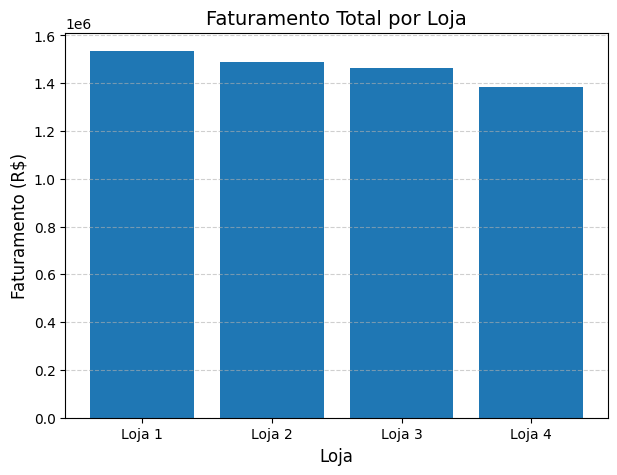

In [29]:
# Dicionário com os DataFrames
lojas = {
    'Loja 1': df_loja1,
    'Loja 2': df_loja2,
    'Loja 3': df_loja3,
    'Loja 4': df_loja4
}

# Calcula o faturamento total (somando preços)
faturamento = {nome: df['Preço'].sum() for nome, df in lojas.items()}

# Mostra no terminal
for nome, valor in faturamento.items():
    print(f"{nome}: R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

# Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(faturamento.keys(), faturamento.values())

plt.title('Faturamento Total por Loja', fontsize=14)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


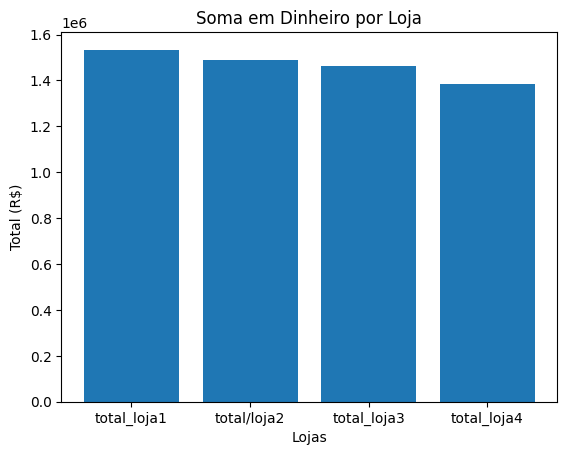

In [18]:
import matplotlib.pyplot as plt

plt.bar(['total_loja1', 'total/loja2', 'total_loja3', 'total_loja4'], [total_loja1, total_loja2, total_loja3, total_loja4])
plt.title('Soma em Dinheiro por Loja')
plt.xlabel('Lojas')
plt.ylabel('Total (R$)')
plt.show()

In [19]:
categoria_mais_popular = df_loja1['Categoria do Produto'].value_counts().idxmax()
quantidade = df_loja1['Categoria do Produto'].value_counts().max()

print(f"A categoria mais popular é '{categoria_mais_popular}' com {quantidade} vendas.")


A categoria mais popular é 'moveis' com 465 vendas.


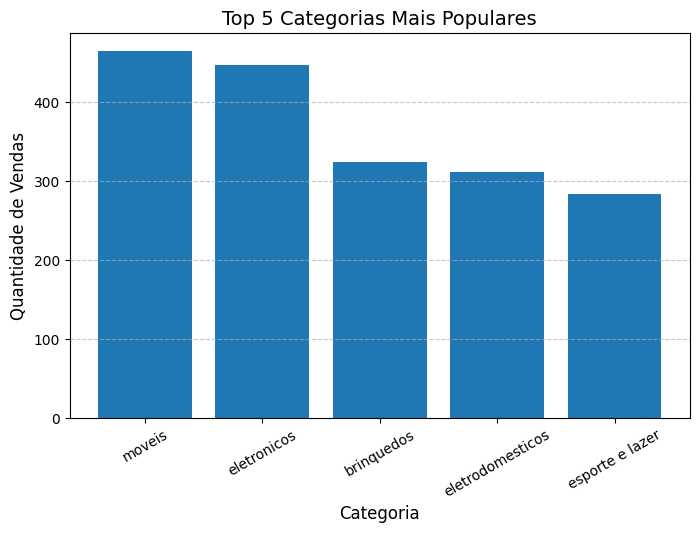

In [20]:
# Contagem das categorias
top5 = df_loja1['Categoria do Produto'].value_counts().head(5)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)

plt.title('Top 5 Categorias Mais Populares', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

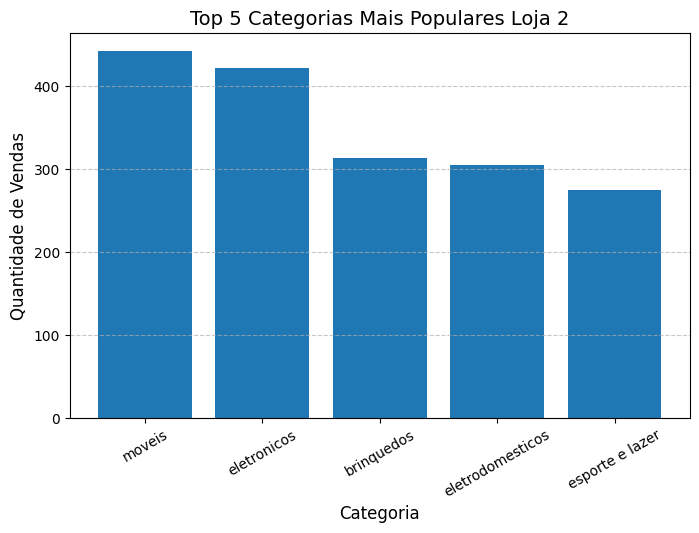

In [30]:
# Contagem das categorias
top5 = df_loja2['Categoria do Produto'].value_counts().head(5)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)

plt.title('Top 5 Categorias Mais Populares Loja 2', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

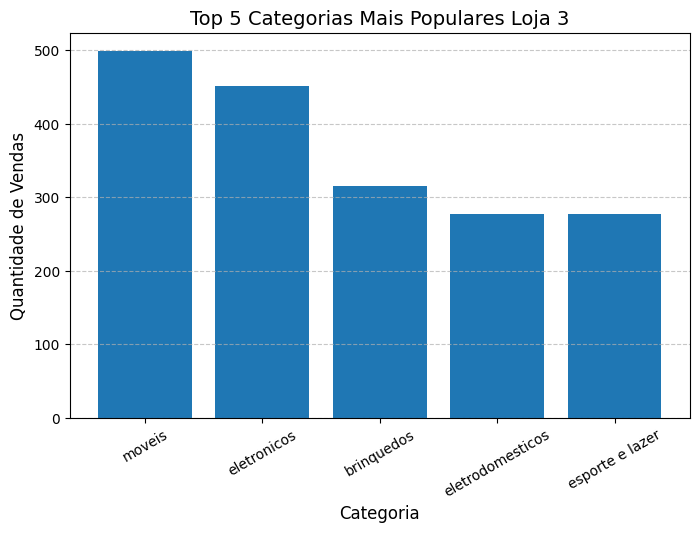

In [31]:
# Contagem das categorias
top5 = df_loja3['Categoria do Produto'].value_counts().head(5)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)

plt.title('Top 5 Categorias Mais Populares Loja 3', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

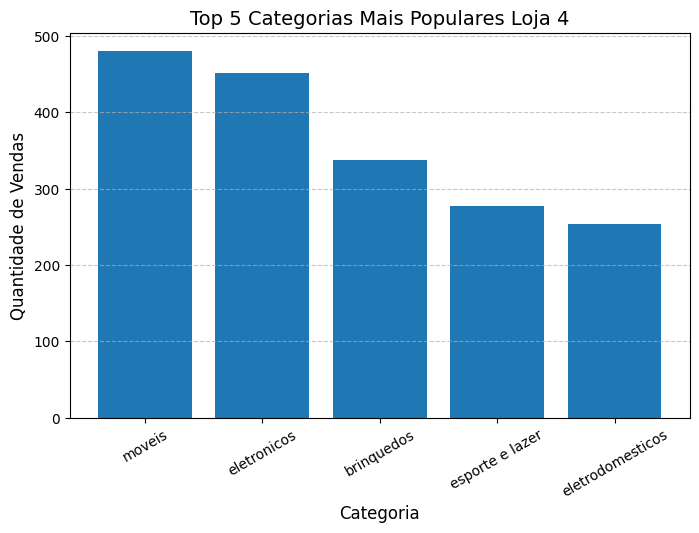

In [32]:
# Contagem das categorias
top5 = df_loja4 ['Categoria do Produto'].value_counts().head(5)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)

plt.title('Top 5 Categorias Mais Populares Loja 4', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

🏆 Top 5 Produtos Mais Vendidos - Loja 2:
Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58
Name: count, dtype: int64


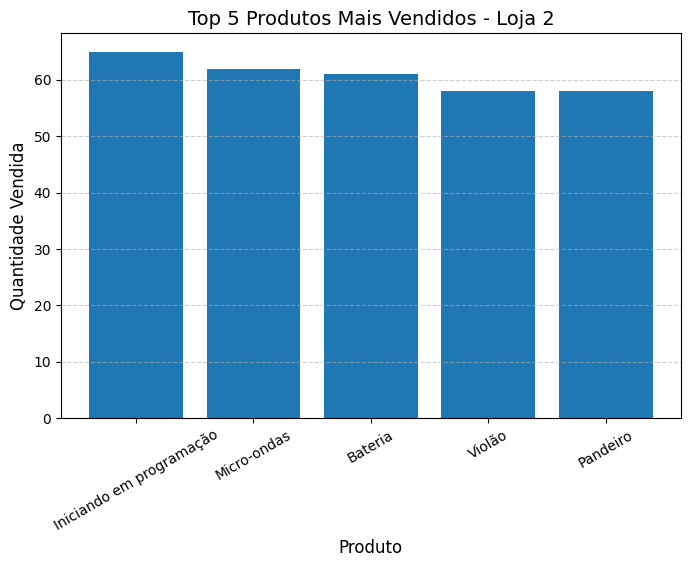

In [25]:
import matplotlib.pyplot as plt

# Top 5 produtos da Loja 2
top5_loja2 = df_loja2['Produto'].value_counts().head(5)

# Mostra no terminal
print("🏆 Top 5 Produtos Mais Vendidos - Loja 2:")
print(top5_loja2)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(top5_loja2.index, top5_loja2.values)

plt.title('Top 5 Produtos Mais Vendidos - Loja 2', fontsize=14)
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


🏆 Top 5 Produtos Mais Vendidos - Loja 3:
Produto
Kit banquetas      57
Cama king          56
Mesa de jantar     56
Jogo de panelas    55
Cômoda             55
Name: count, dtype: int64


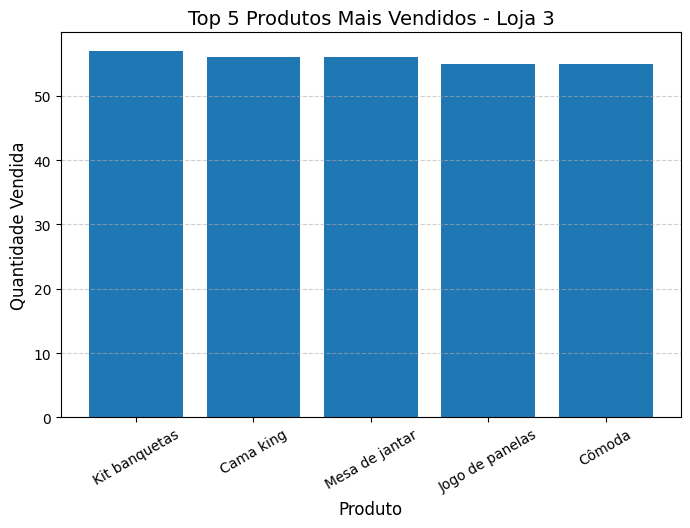

In [26]:
import matplotlib.pyplot as plt

# Top 5 produtos da Loja 2
top5_loja2 = df_loja3['Produto'].value_counts().head(5)

# Mostra no terminal
print("🏆 Top 5 Produtos Mais Vendidos - Loja 3:")
print(top5_loja2)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(top5_loja2.index, top5_loja2.values)

plt.title('Top 5 Produtos Mais Vendidos - Loja 3', fontsize=14)
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


🏆 Top 5 Produtos Mais Vendidos - Loja 4:
Produto
Kit banquetas      57
Cama king          56
Mesa de jantar     56
Jogo de panelas    55
Cômoda             55
Name: count, dtype: int64


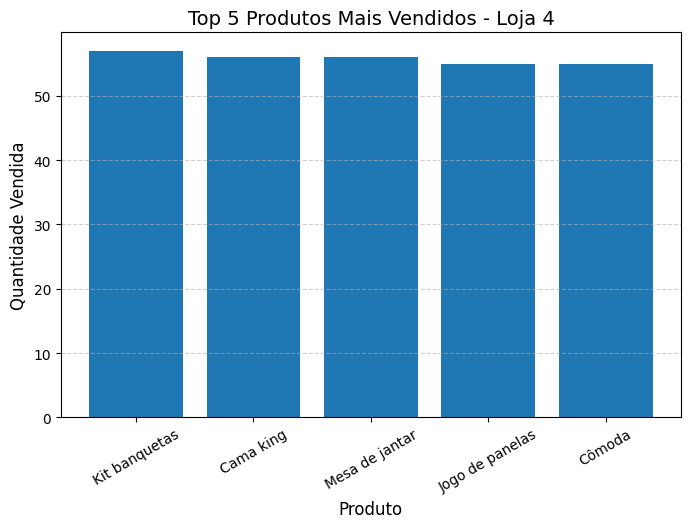

In [27]:
import matplotlib.pyplot as plt

# Top 5 produtos da Loja 2
top5_loja4= df_loja4['Produto'].value_counts().head(5)

# Mostra no terminal
print("🏆 Top 5 Produtos Mais Vendidos - Loja 4:")
print(top5_loja2)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(top5_loja2.index, top5_loja2.values)

plt.title('Top 5 Produtos Mais Vendidos - Loja 4', fontsize=14)
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


🏆 Top 10 Produtos Mais Vendidos (todas as lojas):
Produto
Cômoda                      210
Micro-ondas                 206
Carrinho controle remoto    206
Bateria                     203
Cama king                   201
Jogo de panelas             200
Secadora de roupas          200
Modelagem preditiva         200
Cama box                    199
Blocos de montar            199
Name: count, dtype: int64


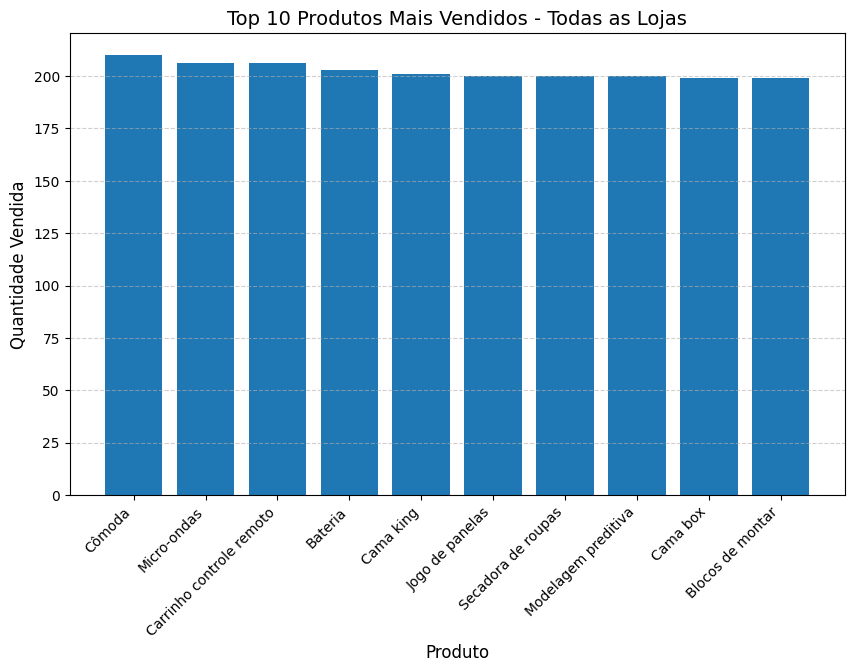

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Junta todos os DataFrames
df_todas = pd.concat([df_loja1, df_loja2, df_loja3, df_loja4])

# Conta quantas vezes cada produto aparece
top_produtos = df_todas['Produto'].value_counts().head(10)

# Mostra no terminal
print("🏆 Top 10 Produtos Mais Vendidos (todas as lojas):")
print(top_produtos)

# Cria o gráfico
plt.figure(figsize=(10,6))
plt.bar(top_produtos.index, top_produtos.values)

plt.title('Top 10 Produtos Mais Vendidos - Todas as Lojas', fontsize=14)
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


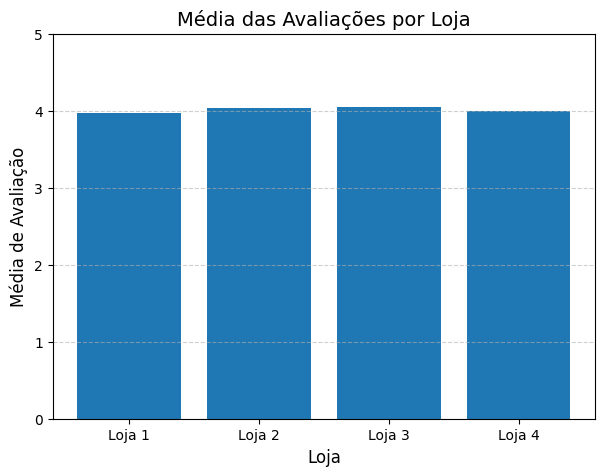

In [21]:
import matplotlib.pyplot as plt

# Dicionário com os DataFrames
lojas = {
    'Loja 1': df_loja1,
    'Loja 2': df_loja2,
    'Loja 3': df_loja3,
    'Loja 4': df_loja4
}

# Calcula a média das avaliações
medias_avaliacoes = {nome: df['Avaliação da compra'].mean() for nome, df in lojas.items()}

# Cria o gráfico
plt.figure(figsize=(7,5))
plt.bar(medias_avaliacoes.keys(), medias_avaliacoes.values())

plt.title('Média das Avaliações por Loja', fontsize=14)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Média de Avaliação', fontsize=12)
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


In [22]:
# Dicionário com os DataFrames
lojas = {
    'Loja 1': df_loja1,
    'Loja 2': df_loja2,
    'Loja 3': df_loja3,
    'Loja 4': df_loja4
}

# Loop para encontrar o produto mais e o menos vendido em cada loja
for nome, df in lojas.items():
    contagem = df['Produto'].value_counts()
    produto_mais = contagem.idxmax()
    qtd_mais = contagem.max()
    produto_menos = contagem.idxmin()
    qtd_menos = contagem.min()

    print(f'🏪 {nome}')
    print(f'   🥇 Mais vendido: {produto_mais} ({qtd_mais} vendas)')
    print(f'   🥀 Menos vendido: {produto_menos} ({qtd_menos} venda(s))')
    print('-'*50)


🏪 Loja 1
   🥇 Mais vendido: TV Led UHD 4K (60 vendas)
   🥀 Menos vendido: Headset (33 venda(s))
--------------------------------------------------
🏪 Loja 2
   🥇 Mais vendido: Iniciando em programação (65 vendas)
   🥀 Menos vendido: Jogo de tabuleiro (32 venda(s))
--------------------------------------------------
🏪 Loja 3
   🥇 Mais vendido: Kit banquetas (57 vendas)
   🥀 Menos vendido: Blocos de montar (35 venda(s))
--------------------------------------------------
🏪 Loja 4
   🥇 Mais vendido: Cama box (62 vendas)
   🥀 Menos vendido: Guitarra (33 venda(s))
--------------------------------------------------


Loja 1: R$ 34.69
Loja 2: R$ 33.62
Loja 3: R$ 33.07
Loja 4: R$ 31.28


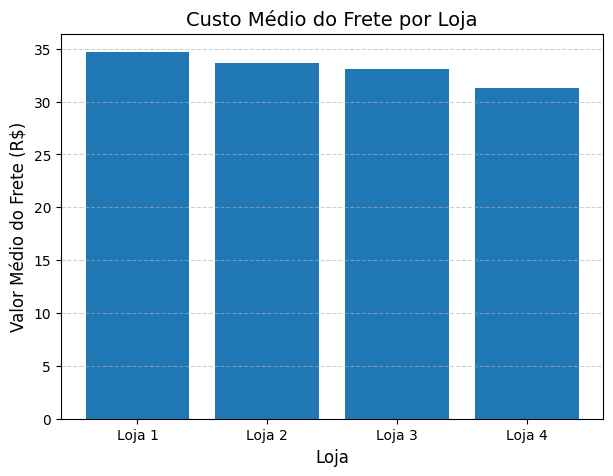

In [23]:
import matplotlib.pyplot as plt

# Dicionário com os DataFrames
lojas = {
    'Loja 1': df_loja1,
    'Loja 2': df_loja2,
    'Loja 3': df_loja3,
    'Loja 4': df_loja4
}

# Calcula o custo médio do frete por loja
frete_medio = {nome: df['Frete'].mean() for nome, df in lojas.items()}

# Exibe as médias no terminal
for nome, valor in frete_medio.items():
    print(f"{nome}: R$ {valor:.2f}")

# Cria o gráfico
plt.figure(figsize=(7,5))
plt.bar(frete_medio.keys(), frete_medio.values())

plt.title('Custo Médio do Frete por Loja', fontsize=14)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Valor Médio do Frete (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
